# Анализ базы данных операционных продаж

# Описание исследования

В нашем распоряжении есть база данных операционных продаж одного из банков.

# Цель исследования

Проанализировать базу данных на предмет каких-либо трендов, зон роста и аномалий. Дать рекомендации отделу операционных продаж.

# Задачи исследования

1. Оценить представленные данные.
2. Выполнить предобработку данных.
3. Провести исследовательский анализ данных.

# Исходные данные

В нашем распоряжении база данных data.db, которая хранит информацию о операционных продаж одного из банков и сотрудниках, занимающихся продажами через исходящие звонки.

# Данное исследование разделим на несколько частей

## Загрузка данных и подготовка их к анализу

### Импортируем и установим необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from IPython.display import Image

#### Установим библиотеку kaleido версии 0.1.0post1

In [2]:
pip install kaleido==0.1.0post1

Note: you may need to restart the kernel to use updated packages.


### Пропишем путь к базе данных

In [3]:
db_path = (r'C:\Users\Равиль\Проекты для портфолио\11. Тестовое задание 2\data.db')

### Сохраняем коннектор

In [4]:
conn = sqlite3.connect(db_path)

### Отобразим все таблицы базы данных data.db

In [5]:
tables = pd.read_sql_query("""SELECT name FROM sqlite_master WHERE type='table'""", conn)
tables

,name
0,mngmnt
1,product
2,queue
3,result
4,horoscope
5,group
6,emp_x_org_gr
7,task
8,action
9,call


### Отобразим содержимое таблиц базы данных

In [6]:
for table_name in tables['name']:
    print(table_name)
    query = f'SELECT * FROM "{table_name}" LIMIT 10'
    display(pd.read_sql_query(query, conn))

mngmnt


,org_management_rk,management_nm
0,401,Управление КЦ Дирис
1,307,Управление КЦ Черс
2,1834,Управление КЦ Помидор
3,689,Управление КЦ Казан
4,1621,Управление КЦ Чизан
5,1856,Управление КЦ Лес
6,1780,Управление КЦ Хирс
7,1833,Управление КЦ Сеньор
8,483,Управление КЦ Нерс
9,687,Управление КЦ Верс


product


,hit_rk,hid,using_flg
0,41296509,4,None
1,22805443,4,None
2,47418895,4,None
3,5426643,4,None
4,53198918,4,None
5,33183184,4,None
6,38178592,2,None
7,13362909,4,None
8,19515997,4,None
9,13103736,2,None


queue


...

,task_rk,task_stage_id,source_system_cd,create_dttm,finish_dttm
0,15431250,18.0,FW,2022-08-25 09:05:53,None
1,93508186,1.0,GI,2022-08-01 05:09:01,2022-08-02 13:35:02
2,357853,1.0,GI,2022-08-08 22:05:30,2022-08-08 22:07:32
3,95793266,1.0,GI,2022-08-04 10:42:46,2022-08-04 13:59:52
4,5014541,1.0,GI,2022-08-14 19:16:43,2022-08-15 11:12:14
5,88979016,1.0,GI,2022-07-26 02:30:46,2022-08-17 16:13:47
6,19952848,1.0,GI,2022-08-31 10:03:58,2022-09-19 16:35:01
7,96182364,23.0,FW,2022-08-04 03:33:02,2022-08-04 06:23:21
8,3805464,23.0,FW,2022-08-12 04:20:30,2022-08-23 11:24:32
9,97493497,1.0,GI,2022-08-05 05:16:54,2022-08-05 11:57:11


action


,hit_rk,hit_status_result_id
0,3962005,2
1,71755300,5
2,38055819,5
3,42283118,2
4,16030098,5
5,34977953,2
6,29778945,1
7,38367698,5
8,78706835,5
9,35080345,5


call


,wo_hit_rk,wo_task_rk,wo_queue_id,agent_login,wo_employee_rk,finish_dttm,duratoin_sec
0,73292106,93625442,12245,lyangama,66749466,2022-08-01 12:52:25,0
1,93763347,98572816,11696,enkoiion,88931008,2022-08-08 10:46:46,"12,53"
2,13988704,91292760,14354,kinalapo,61041016,2022-08-16 14:16:03,0
3,28495290,12470192,14303,kinasgsa,98181009,2022-08-22 18:38:13,0
4,31412029,161228,9264,ikovnisu,47451124,2022-08-23 10:38:24,"128,47"
5,82299889,85191861,14644,atovksip,77811117,2022-08-04 10:53:26,0
6,89329077,98650151,12245,oyankrsh,88658588,2022-08-06 13:32:42,0
7,19715922,9596828,14644,llinirra,59539859,2022-08-18 13:19:21,"71,99"
8,42214192,14854023,13044,novabbmu,11371111,2022-08-26 11:47:11,"208,12"
9,51183929,18611189,13045,ievavamu,4241040,2022-08-30 16:45:57,0


### Объединим все таблицы в одну и отобразим результат объединения

In [7]:
result_table = pd.read_sql_query("""
SELECT
    c.wo_hit_rk                AS call_hit_rk,
    c.wo_task_rk               AS call_task_rk,
    c.wo_queue_id              AS call_queue_id,
    c.agent_login              AS call_agent_login,
    c.wo_employee_rk           AS call_employee_rk,
    c.finish_dttm              AS call_finish_dttm,
    c.duratoin_sec             AS call_duration_sec,
    t.task_stage_id            AS task_stage_id,
    t.source_system_cd         AS task_source_system_cd,
    t.create_dttm              AS task_create_dttm,
    t.finish_dttm              AS task_finish_dttm,
    q.queue_id                 AS queue_id,
    q.queue_desc               AS queue_desc,
    a.hit_status_result_id     AS action_hit_status_result_id,
    r.hit_status_result_desc   AS result_status_desc,
    p.hid                      AS product_hid,
    p.using_flg                AS product_using_flg,
    e.org_group_rk             AS employee_org_group_rk,
    g.group_nm                 AS group_nm,
    g.org_management_rk        AS group_management_rk,
    m.management_nm            AS management_nm,
    h.horoscope                AS agent_horoscope
FROM call AS c
LEFT JOIN task AS t ON c.wo_task_rk = t.task_rk
LEFT JOIN queue AS q ON c.wo_queue_id = q.queue_id
LEFT JOIN action AS a ON c.wo_hit_rk = a.hit_rk
LEFT JOIN result AS r ON a.hit_status_result_id = r.hit_status_result_id
LEFT JOIN product AS p ON a.hit_rk = p.hit_rk
LEFT JOIN emp_x_org_gr AS e ON c.wo_employee_rk = e.employee_rk
LEFT JOIN "group" AS g ON e.org_group_rk = g.org_group_rk
LEFT JOIN mngmnt AS m ON g.org_management_rk = m.org_management_rk
LEFT JOIN horoscope AS h ON c.agent_login = h.agent_login
""", conn)
result_table.head().T

,0,1,2,3,4
call_hit_rk,73292106,93763347,13988704,28495290,31412029
call_task_rk,93625442,98572816,91292760,12470192,161228
call_queue_id,12245,11696,14354,14303,9264
call_agent_login,lyangama,enkoiion,kinalapo,kinasgsa,ikovnisu
call_employee_rk,66749466,88931008,61041016,98181009,47451124
call_finish_dttm,2022-08-01 12:52:25,2022-08-08 10:46:46,2022-08-16 14:16:03,2022-08-22 18:38:13,2022-08-23 10:38:24
call_duration_sec,0,"12,53",0,0,"128,47"
task_stage_id,1.0,1.0,1.0,1.0,1.0
task_source_system_cd,GI,GI,GI,GI,GI
task_create_dttm,2022-08-01 00:46:37,2022-08-06 11:24:23,2022-07-29 04:46:37,2022-08-21 01:55:57,2022-08-08 01:01:35


### Сохраним результат объединения таблиц в файл result_table.csv

In [8]:
result_table.to_csv('result_table.csv', index=False, encoding='utf-8-sig')

### Cчитаем данные из файла result_table.csv

In [9]:
try:
    data = pd.read_csv(r'C:\Users\Равиль\Проекты для портфолио\11. Тестовое задание 2\result_table.csv')
    print("✅ Файл загружен с локального пути")
except:
    try:
        data = pd.read_csv("https://drive.google.com/uc?export=download&id=1xov50UoNJgLq5yCrghWmoxwPJK3OVRq1")
        print("✅ Файл загружен с Google Drive")
    except:
        try:
            data = pd.read_csv("/content/drive/MyDrive/result_table.csv")
            print("✅ Файл загружен из Google Colab")
        except Exception as e:
            print("❌ Ошибка загрузки файла:", e)

✅ Файл загружен с локального пути


### Опишем структуру файла result_table.csv

Структура файла result_table.csv:

    call_hit_rk — ключ коммуникации (звонка) с клиентом, уникальный идентификатор попытки дозвона;
    call_task_rk — внешний ключ на задание, по которому оператор совершает звонок;
    call_queue_id — идентификатор очереди, в рамках которой оператор получил звонок;
    call_agent_login — логин оператора, совершившего звонок;
    call_employee_rk — идентификатор сотрудника (оператора);
    call_finish_dttm — дата и время окончания звонка;
    call_duration_sec — длительность звонка в секундах;
    task_stage_id — идентификатор стадии выполнения задания;
    task_source_system_cd — код источника, из которого пришло задание;
    task_create_dttm — дата и время создания задания;
    task_finish_dttm — дата и время завершения задания;
    queue_id — идентификатор очереди, из которой назначается задание оператору;
    queue_desc — текстовое описание очереди;
    action_hit_status_result_id — идентификтор результата коммуникации;
    result_status_desc — текстовое описание результата звонка;
    product_hid — уникальный идентификатор продукта, который оператор продавал;
    product_using_flg — флаг использования продукта клиентом;
    employee_org_group_rk — идентификатор группы (команды), к которой принадлежит сотрудник;
    group_nm — название группы второго уровня;
    group_management_rk — идентификатор управляющего подразделения, которому принадлежит группа;
    management_nm — название группы первого уровня / управления;
    agent_horoscope — знак зодиака оператора.

### Изучим общую информацию о датафрейме data

In [10]:
data.head().T

,0,1,2,3,4
call_hit_rk,73292106,93763347,13988704,28495290,31412029
call_task_rk,93625442,98572816,91292760,12470192,161228
call_queue_id,12245,11696,14354,14303,9264
call_agent_login,lyangama,enkoiion,kinalapo,kinasgsa,ikovnisu
call_employee_rk,66749466,88931008,61041016,98181009,47451124
call_finish_dttm,2022-08-01 12:52:25,2022-08-08 10:46:46,2022-08-16 14:16:03,2022-08-22 18:38:13,2022-08-23 10:38:24
call_duration_sec,0,"12,53",0,0,"128,47"
task_stage_id,1.0,1.0,1.0,1.0,1.0
task_source_system_cd,GI,GI,GI,GI,GI
task_create_dttm,2022-08-01 00:46:37,2022-08-06 11:24:23,2022-07-29 04:46:37,2022-08-21 01:55:57,2022-08-08 01:01:35


### Выведем основную информацию о датафрейме data

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89174 entries, 0 to 89173
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   call_hit_rk                  89174 non-null  int64  
 1   call_task_rk                 89174 non-null  int64  
 2   call_queue_id                89174 non-null  int64  
 3   call_agent_login             89174 non-null  object 
 4   call_employee_rk             89174 non-null  int64  
 5   call_finish_dttm             89174 non-null  object 
 6   call_duration_sec            89174 non-null  object 
 7   task_stage_id                85383 non-null  float64
 8   task_source_system_cd        89174 non-null  object 
 9   task_create_dttm             89174 non-null  object 
 10  task_finish_dttm             88421 non-null  object 
 11  queue_id                     89172 non-null  float64
 12  queue_desc                   89172 non-null  object 
 13  action_hit_statu

### Выводы по 1 разделу

Таблица data содержит 25 столбцов в которых имеются, целые и вещественные числа и строки.

1. Типом данных в столбцах call_hit_rk, call_task_rk, call_queue_id, call_employee_rk, action_hit_status_result_id, product_hid, employee_org_group_rk, group_management_rk являются целые числа.
2. Типом данных в столбцах task_stage_id, queue_id, product_using_flg являются дробные числа
3. Типом данных в столбцах call_agent_login, call_finish_dttm, call_duration_sec, task_source_system_cd, task_create_dttm, task_finish_dttm, queue_desc, result_status_desc, group_nm, management_nm, agent_horoscope являются строки.

Учитывая типы данных в столбцах, для последующего анализа потребуется преобразование в некоторых из них.

## Предобработка данных

### Изучение и обработка пропусков

#### Опеределим сколько всего есть пропущенных значений в каждом столбце в датафрейма data

In [12]:
data.isna().sum().sort_values(ascending=False)

product_using_flg              86649
task_stage_id                   3791
task_finish_dttm                 753
queue_id                           2
queue_desc                         2
management_nm                      0
group_management_rk                0
group_nm                           0
employee_org_group_rk              0
product_hid                        0
result_status_desc                 0
action_hit_status_result_id        0
call_hit_rk                        0
call_task_rk                       0
task_create_dttm                   0
task_source_system_cd              0
call_duration_sec                  0
call_finish_dttm                   0
call_employee_rk                   0
call_agent_login                   0
call_queue_id                      0
agent_horoscope                    0
dtype: int64

#### Оценим сколько пропущено значений в столбцах в процентах от общего количества

In [13]:
round(data.isna().mean().sort_values(ascending=False) * 100, 4)

product_using_flg              97.1685
task_stage_id                   4.2512
task_finish_dttm                0.8444
queue_id                        0.0022
queue_desc                      0.0022
management_nm                   0.0000
group_management_rk             0.0000
group_nm                        0.0000
employee_org_group_rk           0.0000
product_hid                     0.0000
result_status_desc              0.0000
action_hit_status_result_id     0.0000
call_hit_rk                     0.0000
call_task_rk                    0.0000
task_create_dttm                0.0000
task_source_system_cd           0.0000
call_duration_sec               0.0000
call_finish_dttm                0.0000
call_employee_rk                0.0000
call_agent_login                0.0000
call_queue_id                   0.0000
agent_horoscope                 0.0000
dtype: float64

#### Оценим в каких строках есть пропущенные значения в столбце product_using_flg в датафрейме data

In [14]:
data.loc[data['product_using_flg'].isna()].head(6).T

,0,1,2,3,4,5
call_hit_rk,73292106,93763347,13988704,28495290,31412029,82299889
call_task_rk,93625442,98572816,91292760,12470192,161228,85191861
call_queue_id,12245,11696,14354,14303,9264,14644
call_agent_login,lyangama,enkoiion,kinalapo,kinasgsa,ikovnisu,atovksip
call_employee_rk,66749466,88931008,61041016,98181009,47451124,77811117
call_finish_dttm,2022-08-01 12:52:25,2022-08-08 10:46:46,2022-08-16 14:16:03,2022-08-22 18:38:13,2022-08-23 10:38:24,2022-08-04 10:53:26
call_duration_sec,0,"12,53",0,0,"128,47",0
task_stage_id,1.0,1.0,1.0,1.0,1.0,1.0
task_source_system_cd,GI,GI,GI,GI,GI,GI
task_create_dttm,2022-08-01 00:46:37,2022-08-06 11:24:23,2022-07-29 04:46:37,2022-08-21 01:55:57,2022-08-08 01:01:35,2022-07-22 17:38:27


#### Оценим в каких строках есть пропущенные значения в столбце task_stage_id в датафрейме data

In [15]:
data.loc[data['task_stage_id'].isna()].head(6).T

,16,29,135,161,163,198
call_hit_rk,38604691,84350406,5122080,39637884,93361754,33389237
call_task_rk,11928680,96433247,3654983,12025439,98701907,9696067
call_queue_id,8159,8071,8159,8159,14110,8159
call_agent_login,erovreal,rimaimpr,kovapkku,hevasxku,zlovmema,laevaaba
call_employee_rk,69071126,53083530,21131042,39131073,13979813,27441012
call_finish_dttm,2022-08-25 12:28:48,2022-08-04 04:17:51,2022-08-12 16:33:45,2022-08-25 12:47:15,2022-08-08 16:17:45,2022-08-23 12:05:40
call_duration_sec,0,0,"92,45",0,"69,21",0
task_stage_id,NaN,NaN,NaN,NaN,NaN,NaN
task_source_system_cd,CM,CM,CM,CM,CM,CM
task_create_dttm,2022-08-20 05:10:06,2022-08-04 01:00:21,2022-08-12 13:15:51,2022-08-21 05:08:54,2022-08-07 02:30:18,2022-08-19 15:20:35


#### Оценим в каких строках есть пропущенные значения в столбце task_finish_dttm в датафрейме data

In [16]:
data.loc[data['task_finish_dttm'].isna()].head(6).T

,266,319,483,568,648,692
call_hit_rk,49849,38345451,93098201,46417845,17478445,52655324
call_task_rk,1940486,14672787,97630559,17624206,8089304,16380512
call_queue_id,1281,14644,7508,14644,1281,14644
call_agent_login,8221aigu,aevaoako,linaammi,2103lvse,8864nvko,rovagish
call_employee_rk,1611120,61931076,71961117,42569742,55761035,85664985
call_finish_dttm,2022-08-10 15:17:40,2022-08-25 14:21:36,2022-08-08 15:00:07,2022-08-29 13:51:57,2022-08-17 10:50:39,2022-08-31 16:07:16
call_duration_sec,110,0,"15,34",0,"85,09",0
task_stage_id,17.0,3.0,6.0,3.0,17.0,6.0
task_source_system_cd,FW,GI,GI,GI,FW,GI
task_create_dttm,2022-08-10 15:16:08,2022-08-24 00:32:31,2022-08-05 18:29:46,2022-08-28 01:01:39,2022-08-17 10:49:01,2022-08-26 20:29:00


#### Оценим в каких строках есть пропущенные значения в столбце queue_id в датафрейме data

In [17]:
data.loc[data['queue_id'].isna()].head(6).T

,6862,25381
call_hit_rk,40172071,84433959
call_task_rk,10090504,96043819
call_queue_id,483,13620
call_agent_login,6817avsh,hinasigr
call_employee_rk,68361116,91059791
call_finish_dttm,2022-08-25 14:16:32,2022-08-04 15:20:25
call_duration_sec,"41,48","95,53"
task_stage_id,1.0,23.0
task_source_system_cd,GI,FW
task_create_dttm,2022-08-19 22:01:26,2022-08-04 05:52:43


#### Оценим в каких строках есть пропущенные значения в столбце queue_desc в датафрейме data

In [18]:
data.loc[data['queue_desc'].isna()].head(6).T

,6862,25381
call_hit_rk,40172071,84433959
call_task_rk,10090504,96043819
call_queue_id,483,13620
call_agent_login,6817avsh,hinasigr
call_employee_rk,68361116,91059791
call_finish_dttm,2022-08-25 14:16:32,2022-08-04 15:20:25
call_duration_sec,"41,48","95,53"
task_stage_id,1.0,23.0
task_source_system_cd,GI,FW
task_create_dttm,2022-08-19 22:01:26,2022-08-04 05:52:43


### Изучение дубликатов в датафрейме

#### Проверим есть ли явные дубликаты в датафрейме data

In [19]:
data.duplicated().sum()

0

### Изменение типов данных в столбцах

#### Сменим тип данных столбцов queue_id, task_stage_id, product_using_flg датафрейма data с дробных чисел на целые

In [20]:
data['queue_id'] = data['queue_id'].astype('Int64')
data['task_stage_id'] = data['task_stage_id'].astype('Int64')
data['product_using_flg'] = data['product_using_flg'].astype('Int64')

#### Заменим запятые на точки в разделителе целой и дробной части в столбце call_duration_sec датафрейма data

In [21]:
data['call_duration_sec'] = data['call_duration_sec'].astype(str).str.replace(',', '.')

#### Сменим тип данных столбца call_duration_sec датафрейма data из строк в дробные числа

In [22]:
data['call_duration_sec'] = pd.to_numeric(data['call_duration_sec'], errors='coerce')

#### Сменим тип данных столбцов call_finish_dttm, task_create_dttm и task_finish_dttm датафрейма data из строк в формат даты и времени

In [23]:
data['call_finish_dttm'] = pd.to_datetime(data['call_finish_dttm'])
data['task_create_dttm'] = pd.to_datetime(data['task_create_dttm'])
data['task_finish_dttm'] = pd.to_datetime(data['task_finish_dttm'])

#### Оценим изменения после преобразования типов данных

In [24]:
data.info()
data.head(5).T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89174 entries, 0 to 89173
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   call_hit_rk                  89174 non-null  int64         
 1   call_task_rk                 89174 non-null  int64         
 2   call_queue_id                89174 non-null  int64         
 3   call_agent_login             89174 non-null  object        
 4   call_employee_rk             89174 non-null  int64         
 5   call_finish_dttm             89174 non-null  datetime64[ns]
 6   call_duration_sec            89174 non-null  float64       
 7   task_stage_id                85383 non-null  Int64         
 8   task_source_system_cd        89174 non-null  object        
 9   task_create_dttm             89174 non-null  datetime64[ns]
 10  task_finish_dttm             88421 non-null  datetime64[ns]
 11  queue_id                     89172 non-nu

,0,1,2,3,4
call_hit_rk,73292106,93763347,13988704,28495290,31412029
call_task_rk,93625442,98572816,91292760,12470192,161228
call_queue_id,12245,11696,14354,14303,9264
call_agent_login,lyangama,enkoiion,kinalapo,kinasgsa,ikovnisu
call_employee_rk,66749466,88931008,61041016,98181009,47451124
call_finish_dttm,2022-08-01 12:52:25,2022-08-08 10:46:46,2022-08-16 14:16:03,2022-08-22 18:38:13,2022-08-23 10:38:24
call_duration_sec,0.0,12.53,0.0,0.0,128.47
task_stage_id,1,1,1,1,1
task_source_system_cd,GI,GI,GI,GI,GI
task_create_dttm,2022-08-01 00:46:37,2022-08-06 11:24:23,2022-07-29 04:46:37,2022-08-21 01:55:57,2022-08-08 01:01:35


### Выводы по предобработке данных

1. В таблице data есть пропуски в столбцах product_using_flg (86649 пропусков или 97.17%), task_stage_id (3791 пропуск или 4.25%), task_finish_dttm (753 пропуска или 0.84%), queue_id и queue_desc - по 2 пропуска или 0.0022%.
2. Основной причиной появления пропусков в таблице data является то, что в исходных таблицах, участвующих в объединении в SQL запросе, отсутствуют соответствующие записи или значения по ключевым полям.
3. Так как в запросе используются операторы LEFT JOIN, все строки из основной таблицы call сохраняются, даже если в связанных таблицах нет совпадающих записей. В результате для таких строк значения полей из присоединённых таблиц остаются пустыми (NULL).
4. Таким образом, пропуски не являются ошибкой объединения, а отражают реальное отсутствие данных в источниках.
5. Они указывают на то, что, например:
   - не у всех звонков есть связанные задания (task_stage_id, task_finish_dttm);
   - не для всех действий зафиксированы продажи (product_using_flg);
   - отдельные звонки не связаны с конкретной очередью (queue_id, queue_desc).
6. Для последующего анализа и удоства представления были преобразованы:
   - столбцы queue_id, task_stage_id, product_using_flg с дробных чисел на целые;
   - столбец call_duration_sec из строк в дробные числа;
   - столбцы call_finish_dttm, task_create_dttm и task_finish_dttm из строк в формат даты и времени.

#### Рекомендации по дальнейшему анализу обработки пропусков

1. Провести анализ источников данных, чтобы убедиться, что отсутствующие значения действительно не фиксируются на этапе загрузки (например, не создаются задания или продукты для отдельных звонков).
2. Если количество пропусков в отдельных полях (например, product_using_flg) критично для бизнес-показателей — рассмотреть возможность уточнения логики выгрузки или дообогащения данных из дополнительных источников.

## Исследовательский анализ данных

### Добавление новых столбцов

#### Создадим функцию categorize_call, которая будет категоризировать звонки на успешные и не успешныe

In [25]:
def categorize_call(row):
    """Категоризация звонков: 1 — успешный, 0 — неуспешный"""
    if pd.notna(row) and 'успеш' in str(row).lower():
        return 1
    else:
        return 0

#### Применим функцию categorize_call для создания столбца is_success_call, обозначающего факт успешности звонка и проверим результат

In [26]:
data['is_success_call'] = data['result_status_desc'].apply(categorize_call)
data.head().T

,0,1,2,3,4
call_hit_rk,73292106,93763347,13988704,28495290,31412029
call_task_rk,93625442,98572816,91292760,12470192,161228
call_queue_id,12245,11696,14354,14303,9264
call_agent_login,lyangama,enkoiion,kinalapo,kinasgsa,ikovnisu
call_employee_rk,66749466,88931008,61041016,98181009,47451124
call_finish_dttm,2022-08-01 12:52:25,2022-08-08 10:46:46,2022-08-16 14:16:03,2022-08-22 18:38:13,2022-08-23 10:38:24
call_duration_sec,0.0,12.53,0.0,0.0,128.47
task_stage_id,1,1,1,1,1
task_source_system_cd,GI,GI,GI,GI,GI
task_create_dttm,2022-08-01 00:46:37,2022-08-06 11:24:23,2022-07-29 04:46:37,2022-08-21 01:55:57,2022-08-08 01:01:35


#### Добавим новый столбец task_duration, который будет означать время выполения задания оператором в днях и проверим результат добавления

In [27]:
data['task_duration'] = data['task_finish_dttm'] - data['task_create_dttm']
data['task_duration'] = data['task_duration'].dt.total_seconds() / 86400
data.head().T

,0,1,2,3,4
call_hit_rk,73292106,93763347,13988704,28495290,31412029
call_task_rk,93625442,98572816,91292760,12470192,161228
call_queue_id,12245,11696,14354,14303,9264
call_agent_login,lyangama,enkoiion,kinalapo,kinasgsa,ikovnisu
call_employee_rk,66749466,88931008,61041016,98181009,47451124
call_finish_dttm,2022-08-01 12:52:25,2022-08-08 10:46:46,2022-08-16 14:16:03,2022-08-22 18:38:13,2022-08-23 10:38:24
call_duration_sec,0.0,12.53,0.0,0.0,128.47
task_stage_id,1,1,1,1,1
task_source_system_cd,GI,GI,GI,GI,GI
task_create_dttm,2022-08-01 00:46:37,2022-08-06 11:24:23,2022-07-29 04:46:37,2022-08-21 01:55:57,2022-08-08 01:01:35


### Исследование уникальных значений

#### Проверим сколько уникальных значений представлено в каждом столбце датафрейма data

In [28]:
data.nunique().sort_values(ascending=False)

call_hit_rk                    89174
call_finish_dttm               85032
call_task_rk                   50000
task_finish_dttm               48376
task_create_dttm               47953
task_duration                  47443
call_duration_sec              17209
call_employee_rk                1962
call_agent_login                1962
call_queue_id                    157
queue_id                         155
queue_desc                       155
employee_org_group_rk             52
group_nm                          52
group_management_rk               45
management_nm                     45
agent_horoscope                   12
task_stage_id                      9
action_hit_status_result_id        7
result_status_desc                 7
product_hid                        4
task_source_system_cd              3
product_using_flg                  2
is_success_call                    2
dtype: int64

#### Выводы:
1. В датасете представлено 1962 логина операторов, которые распределены по 52 группам 2 уровня под управлением 45 групп первого уровня.
2. Всего имеется 4 продукта, которые продают операторы.
3. Всего имеется 9 стадий выполнения задания.

### Исследование длительности звонка

#### Выведем описательную статистику по длительности звонка

In [29]:
data['call_duration_sec'].describe()

count    89174.000000
mean        48.707301
std         95.087202
min          0.000000
25%          0.000000
50%          0.000000
75%         94.657500
max       5874.710000
Name: call_duration_sec, dtype: float64

#### Построим диаграмму размаха по длительности звонка

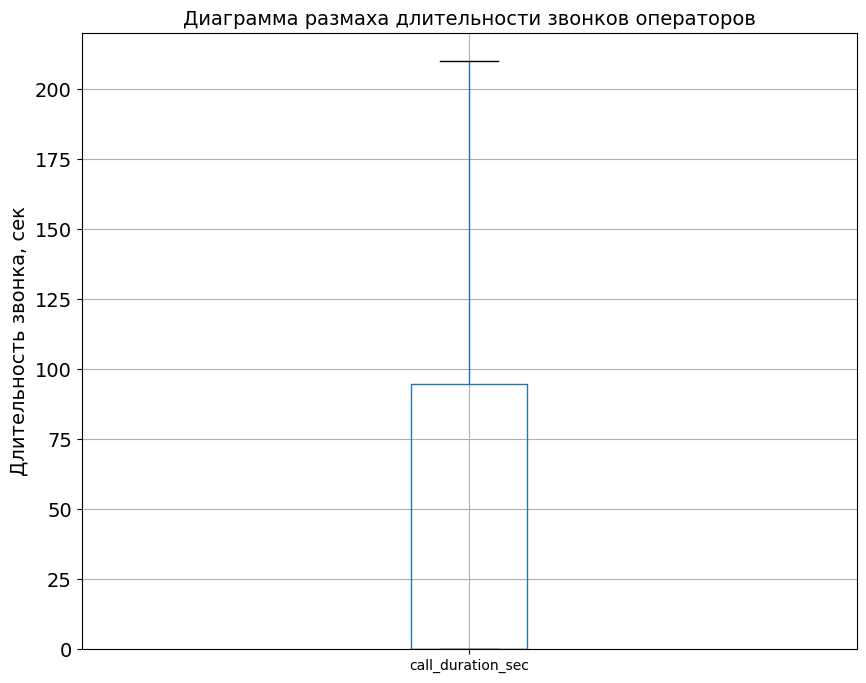

In [30]:
plt.figure(figsize=(10, 8))
plt.ylim(0, 220)
data.boxplot('call_duration_sec')
plt.title('Диаграмма размаха длительности звонков операторов', fontsize=14)
plt.ylabel('Длительность звонка, сек', fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### Построим гистограмму распределения длительности звонка

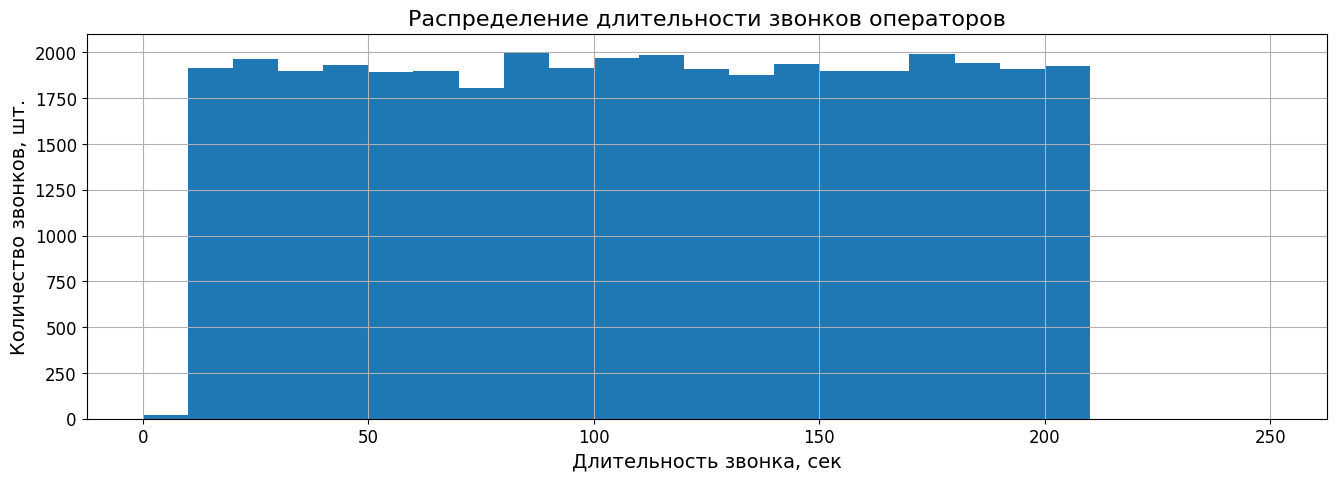

In [31]:
data['call_duration_sec'].hist(figsize=(16, 5), bins=25, range=(0.01, 250))
plt.xlabel('Длительность звонка, сек', fontsize=14)
plt.ylabel('Количество звонков, шт.', fontsize=14)
plt.title('Распределение длительности звонков операторов', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

#### Выведем строки датафрейма data c длительностью звонка более 5000 секунд

In [32]:
data.query('call_duration_sec > 5000').T

,2893,4892,20205,30592,51827,57363,74463,86554
call_hit_rk,7004334,37991719,88277296,28587071,46477147,91321736,85520811,736504
call_task_rk,4571515,15996366,87691094,12229825,17783627,283588,96904342,2713650
call_queue_id,8725,4081,10551,12728,10236,10551,13062,4081
call_agent_login,0212legr,0212legr,0212legr,0212legr,0212legr,0212legr,0212legr,0212legr
call_employee_rk,19079719,19079719,19079719,19079719,19079719,19079719,19079719,19079719
call_finish_dttm,2022-08-13 16:19:07,2022-08-25 20:53:14,2022-08-06 15:02:53,2022-08-22 11:51:39,2022-08-29 20:13:41,2022-08-08 20:33:55,2022-08-05 10:19:54,2022-08-11 15:51:18
call_duration_sec,5874.71,5538.99,5541.05,5117.45,5829.15,5125.12,5013.9,5042.92
task_stage_id,1,1,1,1,1,1,1,1
task_source_system_cd,GI,GI,GI,GI,GI,GI,GI,GI
task_create_dttm,2022-08-13 14:17:38,2022-08-25 18:56:38,2022-07-25 07:58:00,2022-08-21 16:02:56,2022-08-29 14:46:02,2022-08-08 17:50:02,2022-08-04 20:59:51,2022-08-11 12:47:44


#### Выведем строки датафрейма data с оператором 0212legr

In [33]:
data.query('call_agent_login == "0212legr"')[['call_agent_login', 'call_duration_sec', 'group_nm', \
           'management_nm', 'task_source_system_cd']].sort_values('call_duration_sec').reset_index()

,index,call_agent_login,call_duration_sec,group_nm,management_nm,task_source_system_cd
0,89006,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
1,43542,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
2,48898,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
3,53678,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
4,39494,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
5,55383,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
6,34567,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
7,32266,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
8,56651,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI
9,26815,0212legr,0.00,Группа 36,Управление КЦ Чизан,GI


#### Определим у каких операторов длительность звонков составляет более 1000 секунд и сколько таких звонков

In [34]:
data.query('call_duration_sec > 1000')['call_agent_login'].value_counts().reset_index()

,index,call_agent_login
0,0212legr,32


#### Определим у каких операторов длительность звонков составляет более 210 секунд и сколько таких звонков

In [35]:
data.query('call_duration_sec > 210')['call_agent_login'].value_counts().reset_index()

,index,call_agent_login
0,0212legr,32


#### Определим количестов звонков оператора 0212legr

In [36]:
len(data.query('call_agent_login == "0212legr"'))

53

#### Определим количестов звонков оператора 0212legr с длительностью 0 секунд и долю этих звонков от общего количество звонков оператора

In [37]:
print(len(data.query('call_agent_login == "0212legr" & call_duration_sec == 0')))
print()
print(round((len(data.query('call_agent_login == "0212legr" & call_duration_sec == 0'))/\
             len(data.query('call_agent_login == "0212legr"'))*100), 2))

21

39.62


#### Оценим количество и долю звонков с длительностью 0 секунд

In [38]:
print((data['call_duration_sec'] == 0).sum())
print()
print(round((((data['call_duration_sec'] == 0).sum() / len(data['call_duration_sec'])) * 100), 2))

50651

56.8


#### Построим сводную таблицу data_pivot_result методом pivot() со следующими столбцами:
    result_status_desc - статус результата звонка
    count_result_desc - количество звонков с таким статусом
    call_duration_min - минимальная длительность звонка в этом статусе
    call_duration_max - максимальная длительность звонка в этом статусе
    call_duration_mean - средня длительность звонка в этом статусе
    count_result_desc_percent - количество звонков с таким статусом в процентах от общего количества

In [39]:
data_pivot_result = data.pivot_table(index=['result_status_desc'], values='call_duration_sec', aggfunc=['count',\
                                                                                'min', 'max', 'mean']).reset_index()
data_pivot_result.columns = ['result_status_desc', 'count_result_desc', 'call_duration_min', 'call_duration_max', \
                             'call_duration_mean']
data_pivot_result['count_call_percent'] = round((data_pivot_result['count_result_desc'] /\
                                                 data_pivot_result['count_result_desc'].sum())*100, 2)
data_pivot_result = data_pivot_result.sort_values(by = 'count_result_desc', ascending = False).reset_index(drop = True)
data_pivot_result

,result_status_desc,count_result_desc,call_duration_min,call_duration_max,call_duration_mean,count_call_percent
0,Недозвон,50461,0.00,0.00,0.000000,56.59
1,"Дозвон, Отказ",18459,10.00,5874.71,112.487501,20.70
2,"Дозвон, Перезвонить",15108,0.00,5829.15,112.119014,16.94
3,"Дозвон, Успешно",3310,0.00,5042.92,110.175353,3.71
4,"Дозвон, Отложить",1680,10.10,5013.90,122.785708,1.88
5,Не было звонка,130,0.00,0.00,0.000000,0.15
6,"Дозвон, Некорректное задание по звонку",26,10.44,164.14,83.216538,0.03


#### Построим столбчатую диаграмму распределения статусов результата звонка операторов

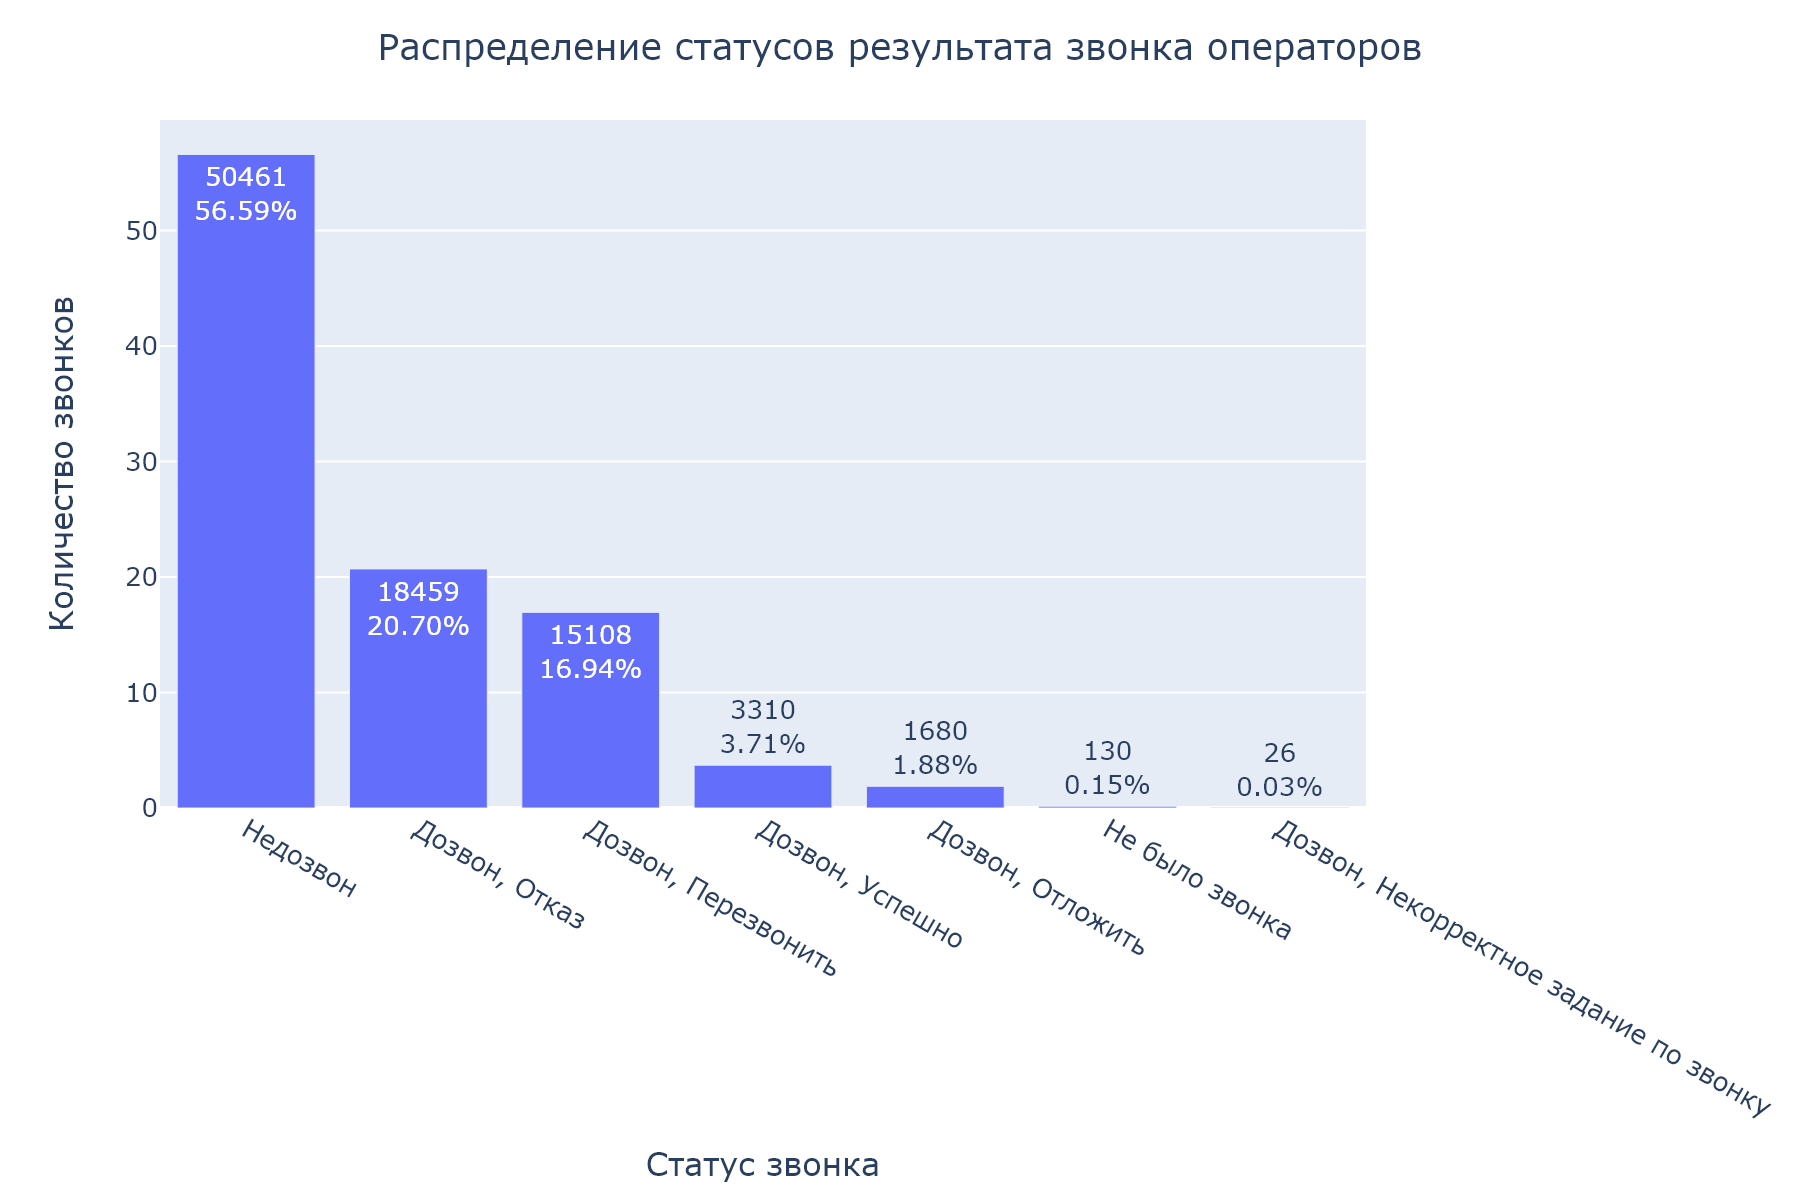

In [40]:
data_pivot_result['text'] = data_pivot_result.apply(lambda x: \
                                        f'{x["count_result_desc"]:.0f}<br>{x["count_call_percent"]:.2f}%', axis=1)
fig = px.bar(data_pivot_result,
             x='result_status_desc',
             y='count_call_percent',
             text='text')
fig.update_layout(title='Распределение статусов результата звонка операторов', title_x=0.5,
                  xaxis_title='Статус звонка',
                  yaxis_title='Количество звонков',
                  width=990,
                  height=600,
                  font_size=13)
pio.write_image(fig, 'figure.png', width=900, height=600, scale=2)
Image('figure.png')

#### Выводы:
1. Основное количество звонков операторов происходит с длительностью от 10 и до 210 секунд.
2. Средняя продолжительность звонка составляет 48.71 секунд.
3. Медианная длительность звонка составляет 0 секунд. Данаая ситуация связана с тем, что 50651 звонок или 56.8 % звонков имеют длительность 0 секунд, то есть фактически не состоялись.
4. С нулевой длительностью были звонки со статусом "Недозвон" (50461 звонков или 56.59%) и "Не было звонка" (130 звонков или 0.15%).
5. При этом вызывают подозрения звонки с нулевой длительностью со статусом "Дозвон, Перезвонить" и "Дозвон, Успешно". Если это не является техничеким сбоем, то выглядит так, что операторы могут припысывать себе успешные звонки, чтобы повысить себе показатели.
6. Максимальная длительность звонка составляет 5874.71 секунд, что составляет почти 98 минут.
7. Все звонки с длительностью более 210 секунд или 3.5 минут присутствуют у оператора 0212legr Группа 36 Управление КЦ Чизан и считаются выбросами по диаграмме размаха длительности звонка. У данного оператора имеются 53 звонка 21 из которых или имеет 39.62% имеет нулевую длительность. Все остальные звонки имеют длительность более 1000 секунд, то есть более 16 минут, что выглядит достаточно подозрительно, так как это не нормальная длительность звонка, где предлагается продавать продукты операторам по телефону.

### Оценка прозводительности и успешности операторов и групп управления

#### Построим сводную таблицу data_pivot_management методом pivot_table() со следующими столбцами:
    management_nm - название группы управления первого уровня
    count_call - количество звонков, совершенной группой
    is_success_call_mean - доля успешных звонков, совершенной группой
    count_call_percent - количество звонков, совершенной группой в процентах от общего количества

In [41]:
data_pivot_management = data.pivot_table(index=['management_nm'], values=['call_duration_sec', 'is_success_call'],\
                                    aggfunc={'call_duration_sec': ['count'], 'is_success_call': ['mean']}).reset_index()
data_pivot_management.columns = ['management_nm', 'count_call', 'is_success_call_mean']
data_pivot_management['count_call_percent'] = round((data_pivot_management['count_call']/
                                                     data_pivot_management['count_call'].sum())*100, 2)
data_pivot_management = data_pivot_management.sort_values(by = ['is_success_call_mean', 'count_call'], ascending = \
                                                          False).reset_index(drop = True)
data_pivot_management

,management_nm,count_call,is_success_call_mean,count_call_percent
0,Управление КЦ Дилис,58,0.224138,0.07
1,Управление КЦ Ребус,802,0.174564,0.90
2,Управление КЦ Хирс,1274,0.153061,1.43
3,Управление КЦ Керс,2361,0.125794,2.65
4,Управление КЦ Шоколад,1831,0.069361,2.05
5,Управление КЦ Дирис,2208,0.069293,2.48
6,Управление КЦ Варис,69,0.057971,0.08
7,Управление КЦ Чирис,142,0.049296,0.16
8,Управление КЦ Мазан,2715,0.044936,3.04
9,Управление КЦ Чирим,47,0.042553,0.05


#### Построим сводную таблицу data_pivot_group методом pivot_table() со следующими столбцами:
    group_nm - название группы второго уровня
    management_nm - название группы управления первого уровня
    count_call - количество звонков, совершенной группой второго уровня
    is_success_call_mean - доля успешных звонков, совершенной группой
    count_call_percent - количество звонков, совершенной группой второго уровня в процентах от общего количества

In [42]:
data_pivot_group = data.pivot_table(index=['group_nm', 'management_nm'], values=['call_duration_sec', 'is_success_call'],\
                                    aggfunc={'call_duration_sec': ['count'], 'is_success_call': ['mean']}).reset_index()
data_pivot_group.columns = ['group_nm', 'management_nm', 'count_call', 'is_success_call_mean']
data_pivot_group['count_call_percent'] = round((data_pivot_group['count_call'] / data_pivot_group['count_call'].sum())\
                                               *100, 2)
data_pivot_group = data_pivot_group.sort_values(by = ['is_success_call_mean', 'count_call'], ascending = \
                                                False).reset_index(drop = True)
data_pivot_group

,group_nm,management_nm,count_call,is_success_call_mean,count_call_percent
0,Группа 6,Управление КЦ Ребус,549,0.236794,0.62
1,Группа 32,Управление КЦ Дилис,58,0.224138,0.07
2,Группа 17,Управление КЦ Керс,1434,0.179219,1.61
3,Группа 2,Управление КЦ Хирс,1274,0.153061,1.43
4,Группа 37,Управление КЦ Страница,672,0.116071,0.75
5,Группа 15,Управление КЦ Шоколад,1831,0.069361,2.05
6,Группа 13,Управление КЦ Дирис,2208,0.069293,2.48
7,Группа 12,Управление КЦ Варис,69,0.057971,0.08
8,Группа 9,Управление КЦ Чирис,142,0.049296,0.16
9,Группа 45,Управление КЦ Мазан,2715,0.044936,3.04


#### Построим сводную таблицу data_pivot_agent_login методом pivot_table() со следующими столбцами:
    agent_login - логин оператора, совершившего звонок
    group_nm - название группы второго уровня
    management_nm - название группы управления первого уровня
    count_call - количество звонков, совершенного оператором
    call_dur_min - минимальная длительность звонка оператора
    call_dur_max - максимальная длительность звонка оператора
    call_dur_mean - средня длительность звонка оператора
    call_dur_median - медианная длительность звонка оператора
    is_success_call_mean - доля успешных звонков, совершенной оператором
    count_call_percent - количество звонков, совершенной оператором в процентах от общего количества

In [43]:
data_pivot_agent_login = data.pivot_table(index=['call_agent_login', 'group_nm', 'management_nm'], values=\
['call_duration_sec', 'is_success_call'], aggfunc={'call_duration_sec': ['count', 'mean', 'median', 'min', 'max'],\
                                                   'is_success_call': ['mean']}).reset_index()
data_pivot_agent_login.columns = ['agent_login', 'group_nm', 'manage_nm', 'count_call', 'call_dur_max',\
                                  'call_dur_mean', 'call_dur_median', 'call_dur_min', 'is_success_call_mean']
data_pivot_agent_login['count_call_percent'] = round((data_pivot_agent_login['count_call'] /\
                                                      data_pivot_agent_login['count_call'].sum())*100, 2)
data_pivot_agent_login = data_pivot_agent_login[['agent_login', 'group_nm', 'manage_nm', 'count_call', 'call_dur_min',\
                        'call_dur_max', 'call_dur_mean','call_dur_median', 'is_success_call_mean', 'count_call_percent']]
data_pivot_agent_login = data_pivot_agent_login.sort_values(by = ['is_success_call_mean', 'count_call'], ascending =\
                                                            False).reset_index(drop = True)
data_pivot_agent_login.head(30)

,agent_login,group_nm,manage_nm,count_call,call_dur_min,call_dur_max,call_dur_mean,call_dur_median,is_success_call_mean,count_call_percent
0,cyanrser,Группа 36,Управление КЦ Чизан,70,0.00,10.99,1.798286,0.000,1.000000,0.08
1,veevapdi,Группа 37,Управление КЦ Страница,3,81.02,172.01,134.696667,151.060,1.000000,0.00
2,nyanlrti,Группа 36,Управление КЦ Чизан,2,19.78,46.88,33.330000,33.330,1.000000,0.00
3,3645tsle,Группа 37,Управление КЦ Страница,1,97.93,97.93,97.930000,97.930,1.000000,0.00
4,cevakpma,Группа 30,Управление КЦ Чизан,1,73.94,73.94,73.940000,73.940,1.000000,0.00
5,novagasa,Группа 17,Управление КЦ Керс,1,43.40,43.40,43.400000,43.400,1.000000,0.00
6,nyanmpmn,Группа 36,Управление КЦ Чизан,3,66.82,192.61,121.220000,104.230,0.666667,0.00
7,sovadyut,Группа 37,Управление КЦ Страница,5,0.00,191.29,106.460000,100.190,0.600000,0.01
8,6265aavo,Группа 37,Управление КЦ Страница,7,0.00,206.90,81.282857,34.100,0.571429,0.01
9,novassla,Группа 2,Управление КЦ Хирс,8,0.00,113.81,42.441250,34.635,0.500000,0.01


#### Проверим распределение успешных и не успешных звонков операторов в датафреме data

In [44]:
data.groupby('is_success_call')['call_duration_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
is_success_call,,,,,,,,
0,85864.0,46.337749,93.241581,0.0,0.00,0.00,88.98,5874.71
1,3310.0,110.175353,118.904828,0.0,55.55,108.25,161.31,5042.92


#### Построим сводную таблицу data_crosstab_success методом crosstab() со следующими столбцами:
    is_success_call - факт успешности звонка
    count_call - количество звонков по фатку успешности
    count_call_percent - оличество звонков по фатку успешности в процентах от общего количества

In [45]:
data_crosstab_success = pd.crosstab(index=data['is_success_call'], columns=['count_call']).reset_index()
data_crosstab_success['count_call_percent'] = round((data_crosstab_success['count_call'] /\
                                                          data_crosstab_success['count_call'].sum()) * 100, 2)
data_crosstab_success = data_crosstab_success.sort_values(by = 'count_call', ascending = False).reset_index(drop = True)
data_crosstab_success

col_0,is_success_call,count_call,count_call_percent
0,0,85864,96.29
1,1,3310,3.71


#### Построим диаграмму рассеяния зависимости доля успешных звонков операторов от средней длительность звонка

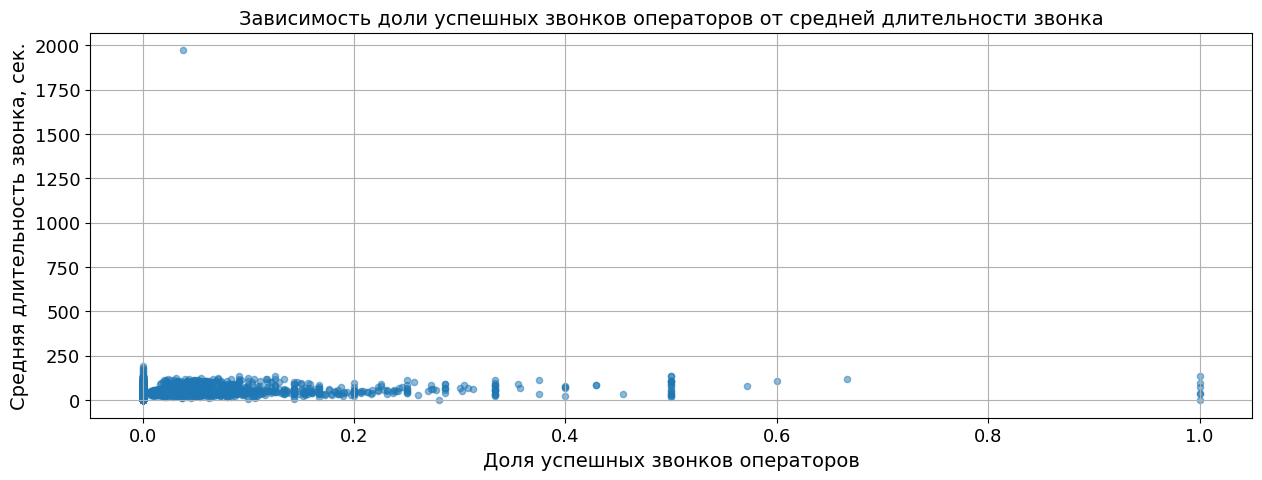

In [46]:
data_pivot_agent_login.plot(x='is_success_call_mean', y='call_dur_mean', kind='scatter', figsize=(15, 5), alpha=0.5)
plt.grid(True)
plt.title('Зависимость доли успешных звонков операторов от средней длительности звонка', fontsize=14)
plt.xlabel('Доля успешных звонков операторов', fontsize=14)
plt.ylabel('Средняя длительность звонка, сек.', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

#### Посчитаем коэффициент корреляции Пирсона между долей успешных звонков операторов и средней длительность звонка

In [47]:
round(data_pivot_agent_login['is_success_call_mean'].corr(data_pivot_agent_login['call_dur_mean']), 3)

0.069

#### Выводы:
1. Наиболее эффективным с точки зрения успешных звонков являются такие группы первого уровня как Управление КЦ Дилис с долей успешных звонков 22,41%, Управление КЦ Ребус - 17,45%, Управление КЦ Хирс- 15,31%, Управление КЦ Керс - 12,58 %. Доля успешности звонков остальных групп первого уровня составляет менее 10%.
2. По этому же показателю среди групп второго уровня выделяются такие группы как Группа 6 - Управления КЦ Ребус - 23,68%, Группа 32	Управления КЦ Дилис - 22,41%, Группа 17  Управления КЦ Керс - 17,92%, Группа 2 - Управления КЦ Хирс - 15,31%, Группа 37 - Управления КЦ Страница - 11,61. Доля успешности звонков остальных групп второго уровня составляет менее 10%.
3. По этому же показателю среди операторов такие операторы как
- cyanrser	Группа 36 Управления КЦ Чизан - 100%,
- veevapdi	Группа 37 Управление КЦ Страница - 100%,
- nyanlrti Группа 36	Управление КЦ Чизан - 100%,
- 3645tsle Группа 37	Управление КЦ Страница - 100%,
- cevakpma	Группа 30 Управление КЦ Чизан - 100%,
- novagasa Группа 17 Управление КЦ Керс - 100%.
У остальных операторов доля успешных звонков составляет менее 100%.
4. При этом подозрения вызывает оператор cyanrser Группа 36 Управление КЦ Чизан, так как он совершил 70 звонков максимальная продолжительность которых составляет 11 секунд, средняя длительность звонка всего 1.8 секунд. Учитывая, что у данного оператора успешность звонков составляет 100% - это выглядит очень странно и есть вероятность, что он может заниматься приписками для повышения своих показателей.
5. Всего успешных звонков 3310 или 3.71 %, неуспешных 85864	или 96.29%. При этом средняя длительность успешного звонка составляет 110.17 секунд, а неуспешного 46.33.
6. При этом коэффициент корреляции Пирсона между долей успешных звонков операторов и средней длительность звонка составляет 0.069, что указывает на очень слабую, практически нулевую линейную зависимость. Это значит, что динные звонки не являются ни признаком успеха, ни признаком неудачи. Операторы, которые говорят дольше, в среднем не более и не менее успешны, чем те, кто решает вопросы быстро.

### Оценка длительности выполнения задания

#### Проверим в каких диапазонах находятся время выдачи и время завершения задания

In [48]:
print(data[['task_create_dttm']].agg(['min', 'max']))
print()
print(data[['task_finish_dttm']].agg(['min', 'max']))

       task_create_dttm
min 2021-03-07 13:47:58
max 2022-08-31 20:53:17

       task_finish_dttm
min 2022-08-01 04:49:49
max 2022-10-22 00:06:38


#### Построим гистограмму распределения длительности выполнения задания операторами

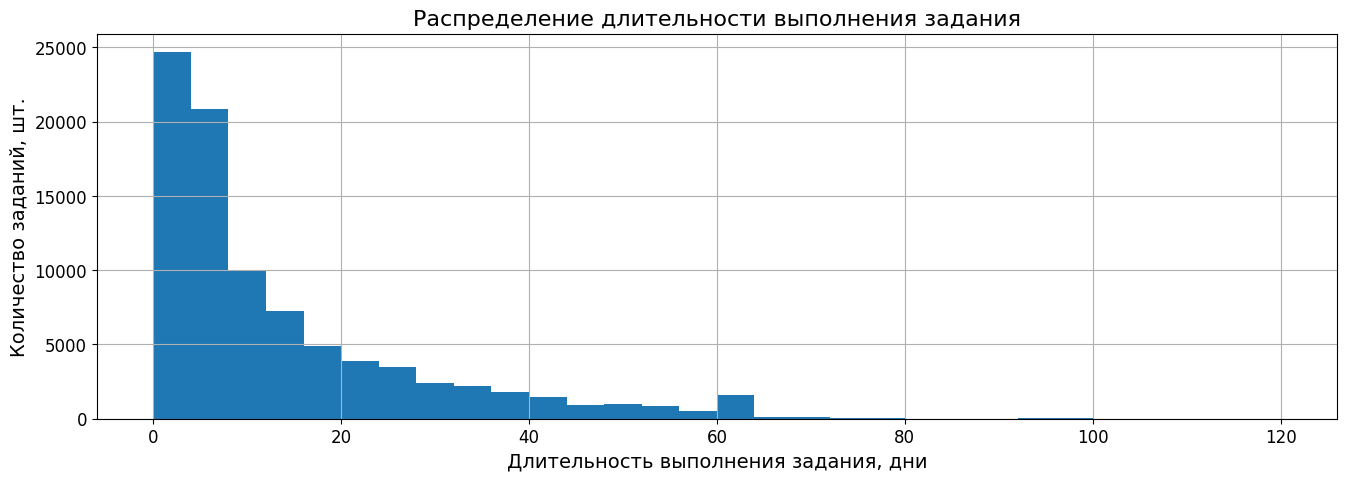

In [49]:
data['task_duration'].hist(figsize=(16, 5), bins=30, range=(0, 120))
plt.xlabel('Длительность выполнения задания, дни', fontsize=14)
plt.ylabel('Количество заданий, шт.', fontsize=14)
plt.title('Распределение длительности выполнения задания', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

#### Выведем описательную статистику по длительности выполнениа задания операторами

In [50]:
data['task_duration'].describe()

count    88421.000000
mean        13.736164
std         16.025470
min          0.000081
25%          3.296655
50%          7.535023
75%         18.800347
max        490.071204
Name: task_duration, dtype: float64

#### Построим диаграмму размаха длительности выполнения задания

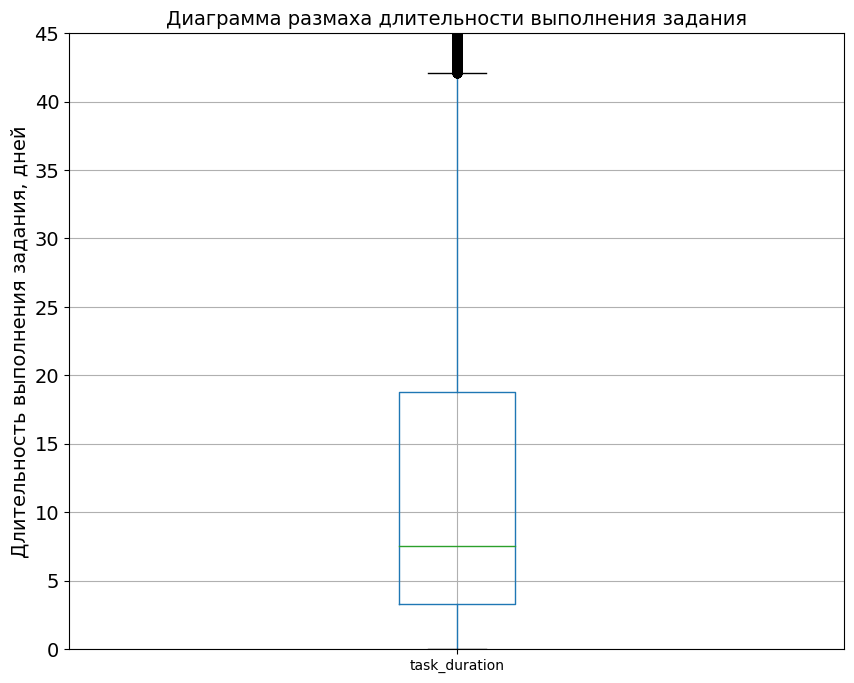

In [51]:
plt.figure(figsize=(10, 8))
plt.ylim(0, 45)
data.boxplot('task_duration')
plt.title('Диаграмма размаха длительности выполнения задания', fontsize=14)
plt.ylabel('Длительность выполнения задания, дней', fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### Построим сводную таблицу data_pivot_task_man методом pivot_table() со следующими столбцами:
    management_nm - название группы управления первого уровня
    count_task - количество выполненных заданий, совершенной группой
    task_duration_mean - среднее время выполнения задания в днях
    count_task_percent - количество выполненных заданий, совершенной группой в процентах от общего количества

In [52]:
data_pivot_task_man = data.pivot_table(index=['management_nm'], values='task_duration', aggfunc=['count',\
                                                                                                 'mean']).reset_index()
data_pivot_task_man.columns = ['management_nm', 'count_task', 'task_duration_mean']
data_pivot_task_man['count_task_percent'] = round((data_pivot_task_man['count_task']/
                                            data_pivot_task_man['count_task'].sum())*100, 3)
data_pivot_task_man = data_pivot_task_man.sort_values(by = ['task_duration_mean', 'count_task'], ascending =\
                                                      [True, False]).reset_index(drop = True)
data_pivot_task_man

,management_nm,count_task,task_duration_mean,count_task_percent
0,Управление КЦ Дирис,2207,4.506408,2.496
1,Управление КЦ Пирс,1424,5.016128,1.610
2,Управление КЦ Чирис,141,6.150753,0.159
3,Управление КЦ Шоколад,1830,6.961151,2.070
4,Управление КЦ Тирс,161,8.145363,0.182
5,Управление КЦ Супер,451,8.694882,0.510
6,Управление КЦ Кирим,1865,8.786167,2.109
7,Управление КЦ Мас,691,8.851783,0.781
8,Управление КЦ Лес,237,9.038905,0.268
9,Управление КЦ Чирим,47,9.465902,0.053


#### Построим сводную таблицу data_pivot_task_group методом pivot_table() со следующими столбцами:
    group_nm - название группы второго уровня
    management_nm - название группы управления первого уровня
    count_task - количество выполненных заданий, совершенной группой второго уровня
    task_duration_mean - среднее время выполнения задания в днях группой второго уровня
    count_task_percent - количество выполненных заданий, совершенной группой второго уровня в процентах от общего количества

In [53]:
data_pivot_task_group = data.pivot_table(index=['group_nm', 'management_nm'], values='task_duration', aggfunc=\
                                         ['count', 'mean']).reset_index()
data_pivot_task_group.columns = ['group_nm', 'management_nm', 'count_task', 'task_duration_mean']
data_pivot_task_group['count_task_percent'] = round((data_pivot_task_group['count_task'] / \
                                                     data_pivot_task_group['count_task'].sum())*100, 3)
data_pivot_task_group = data_pivot_task_group.sort_values(by = ['task_duration_mean', 'count_task'], ascending =\
                                                          [True, False]).reset_index(drop = True)
data_pivot_task_group

,group_nm,management_nm,count_task,task_duration_mean,count_task_percent
0,Группа 13,Управление КЦ Дирис,2207,4.506408,2.496
1,Группа 1,Управление КЦ Пирс,1424,5.016128,1.610
2,Группа 9,Управление КЦ Чирис,141,6.150753,0.159
3,Группа 15,Управление КЦ Шоколад,1830,6.961151,2.070
4,Группа 51,Управление КЦ Тирс,161,8.145363,0.182
5,Группа 42,Управление КЦ Супер,451,8.694882,0.510
6,Группа 21,Управление КЦ Кирим,1865,8.786167,2.109
7,Группа 20,Управление КЦ Мас,691,8.851783,0.781
8,Группа 8,Управление КЦ Лес,237,9.038905,0.268
9,Группа 28,Управление КЦ Кас,524,9.451086,0.593


#### Построим сводную таблицу data_pivot_task_login методом pivot_table() со следующими столбцами:
    agent_login - логин оператора, совершившего звонок
    group_nm - название группы второго уровня
    management_nm - название группы управления первого уровня
    count_task - количество выполненных заданий, совершенного оператором
    task_duration_mean - среднее время выполнения задания в днях оператора
    count_task_percent - количество выполненных заданий оператора в процентах от общего количества

In [54]:
data_pivot_task_login = data.pivot_table(index=['call_agent_login', 'group_nm', 'management_nm'], values='task_duration',\
                                         aggfunc=['count', 'mean']).reset_index()
data_pivot_task_login.columns = ['agent_login', 'group_nm', 'manage_nm', 'count_task', 'task_duration_mean']
data_pivot_task_login['count_task_percent'] = round((data_pivot_task_login['count_task'] / \
                                                     data_pivot_task_login['count_task'].sum())*100, 3)
data_pivot_task_login = data_pivot_task_login.sort_values(by = ['task_duration_mean', 'count_task'], ascending =\
                                                          [True, False]).reset_index(drop = True)
data_pivot_task_login.head(15)

,agent_login,group_nm,manage_nm,count_task,task_duration_mean,count_task_percent
0,cevakpma,Группа 30,Управление КЦ Чизан,1,0.002396,0.001
1,8787ossk,Группа 32,Управление КЦ Дилис,2,0.029491,0.002
2,hevanaxo,Группа 32,Управление КЦ Дилис,1,0.191088,0.001
3,nyanlrti,Группа 36,Управление КЦ Чизан,2,0.280301,0.002
4,syanamsu,Группа 30,Управление КЦ Чизан,1,0.405833,0.001
5,novagmam,Группа 15,Управление КЦ Шоколад,1,0.573102,0.001
6,8082mgro,Группа 36,Управление КЦ Чизан,1,0.636447,0.001
7,rnevvash,Группа 36,Управление КЦ Чизан,1,0.748090,0.001
8,hinagfyu,Группа 17,Управление КЦ Керс,1,0.854317,0.001
9,lkovrmvi,Группа 37,Управление КЦ Страница,1,1.029931,0.001


#### Выведем строки датафрейма data c временем выполнения задания более 490 дней

In [55]:
data.query('task_duration > 490').T

,47793
call_hit_rk,75149186
call_task_rk,65299911
call_queue_id,2221
call_agent_login,0645vnch
call_employee_rk,94969394
call_finish_dttm,2022-08-02 16:11:42
call_duration_sec,0.0
task_stage_id,1
task_source_system_cd,GI
task_create_dttm,2021-04-02 10:25:39


#### Выведем строки датафрейма data с оператором 0645vnch

In [56]:
data.query('call_agent_login == "0645vnch"')[['call_agent_login', 'call_duration_sec', 'group_nm', 'management_nm',\
           'task_source_system_cd', 'task_duration']].sort_values('task_duration').reset_index(drop=True)

,call_agent_login,call_duration_sec,group_nm,management_nm,task_source_system_cd,task_duration
0,0645vnch,45.33,Группа 2,Управление КЦ Хирс,GI,0.028843
1,0645vnch,153.18,Группа 2,Управление КЦ Хирс,GI,0.880023
2,0645vnch,0.00,Группа 2,Управление КЦ Хирс,GI,2.280880
3,0645vnch,74.67,Группа 2,Управление КЦ Хирс,GI,2.739352
4,0645vnch,0.00,Группа 2,Управление КЦ Хирс,GI,4.750544
5,0645vnch,68.80,Группа 2,Управление КЦ Хирс,GI,5.184201
6,0645vnch,201.02,Группа 2,Управление КЦ Хирс,GI,5.423912
7,0645vnch,0.00,Группа 2,Управление КЦ Хирс,GI,6.858600
8,0645vnch,68.79,Группа 2,Управление КЦ Хирс,GI,7.465845
9,0645vnch,105.86,Группа 2,Управление КЦ Хирс,GI,9.430926


#### Определим у каких операторов время выполнения задания составляет более 250 дней сколько таких заданий

In [57]:
data.query('task_duration > 250')['call_agent_login'].value_counts().reset_index()

,index,call_agent_login
0,a137evza,1
1,0645vnch,1
2,hhakevve,1
3,6074vvvl,1
4,3539aako,1
5,anovergi,1
6,rinanyur,1
7,hevatval,1
8,tovanrnu,1
9,9185avis,1


#### Определим количестов заданй оператора 0645vnch

In [58]:
len(data.query('call_agent_login == "0645vnch"'))

33

#### Выводы:
1. Среднее время выполнения задания составляет 13.74 дня. Медианное время составляет 7.54. Медианное время существенно ниже среднего из-за значительных выбросов по данным больше 42 дней.
2. С увеличением количества дней на выполнение задания количество таких заданий заметно уменьшается и становится почти равным нулю при времени выполнения задания более 80 дней.
3. Максимальное время выполнения задания составляет 490 дней, то есть более одного года, что вызывает подозрение и похоже на сбой. Такое время имеется у оператора 0645vnch Группа 2 Управление КЦ Хирс.
5. У 12 операторов имеются единичные задания с длительностью выполнения более 250 дней.
6. По группам первого уровня лидерами по минимальному времени выполнения задания являются Управление КЦ Дирис, Управление КЦ Пирс, Управление КЦ Чирис, Управление КЦ Шоколад со средний временем выполнения заданий от 4,5 до 7 дней.
7. По группам второго уровня Группа 13, Группа 1, Группа 9, Группа 15 с группами управления второго уровня Управление КЦ Дирис, Управление КЦ Пирс, Управление КЦ Чирис и Управление КЦ Шоколад с аналогичными показателями.
8. По операторам лидерами по данном показателю являются:
- cevakpma Группа 30 Управление КЦ Чизан,
- 8787ossk Группа 32 Управление КЦ Дилис,
- hevanaxo Группа 32 Управление КЦ Дилис,
- nyanlrti Группа 36 Управление КЦ Чизан,
- syanamsu Группа 30 Управление КЦ Чизан,
- novagmam Группа 15 Управление КЦ Шоколад,
- 8082mgro Группа 36 Управление КЦ Чизан,
- rnevvash Группа 36 Управление КЦ Чизан,
- hinagfyu Группа 17 Управление КЦ Керс со временем выполнения задания менее 1 дня.

### Оценка распределения продаваемых продуктов

#### Построим сводную таблицу data_crosstab_product методом crosstab() со следующими столбцами:
    product_hid - уникальный идентификатор продаваемого продукта
    count_product_hid - количество уникальных идентификаторов продаваемого продукта
    count_product_hid_percent - количество уникальных идентификаторов продаваемого продукта в процентах от общего количества

In [59]:
data_crosstab_product = pd.crosstab(index=data['product_hid'], columns=['count_product_hid']).reset_index()
data_crosstab_product['count_product_hid_percent'] = round((data_crosstab_product['count_product_hid'] /\
                                                          data_crosstab_product['count_product_hid'].sum()) * 100, 2)
data_crosstab_product = data_crosstab_product.sort_values(by = 'count_product_hid', ascending = False).reset_index(drop\
                                                                                                                 =True)
data_crosstab_product

col_0,product_hid,count_product_hid,count_product_hid_percent
0,4,61410,68.87
1,2,17786,19.95
2,1,6440,7.22
3,3,3538,3.97


#### Выводы:
1. Больше всего операторы звонили по продажам продукта 4 - 61410 звонков или 68.87, на втором мест продукт 2 (17786	звонков или 19.95%), на третьем месте продукт 1 (6440 звонков или 7.22%). Меньше всего операторы продавали продукт 3 (3538 звонков или 3.97%).

## Общие выводы

### Выводы по исследователькому анализу данных

1. Качество и структура данных:

- Данные содержат разнородную информацию о звонках, заданиях и операторах.
- В датасете представлено 1962 логина операторов, которые распределены по 52 группам 2 уровня под управлением 45 групп первого уровня.
- Всего имеется 4 продукта, которые продают операторы.
- Всего имеется 9 стадий выполнения задания.

- Выявлены пропуски (до 97% в product_using_flg), которые являются следствием бизнес-логики (LEFT JOIN), а не ошибок.

- Проведена необходимая предобработка: преобразование типов данных (даты, числа) для анализа.

2. Анализ эффективности звонков:

- Крайне низкая доля успешных звонков — всего 3.71%.

- Обнаружена массовая проблема "нулевых" звонков (56.8% от общего числа), которые не состоялись, но часть из них имеет статус "Успешно", что указывает на возможные приписки.

- Длительность звонка не влияет на его успех (коэффициент корреляции ~0.07). Эффективность оператора не зависит от времени разговора.

- Выявлены наиболее эффективные подразделения Управление КЦ Дилис с долей успешных звонков 22,41%, Управление КЦ Ребус - 17,45%, Управление КЦ Хирс- 15,31%, Управление КЦ Керс - 12,58 %. Доля успешности звонков остальных групп первого уровня составляет менее 10%.

- Выявлены отдельные операторы с подозрительно высокой успешностью звонков в 100% при минимальной длительности звонков:

- cyanrser Группа 36 Управления КЦ Чизан
- veevapdi Группа 37 Управление КЦ Страница
- nyanlrti Группа 36 Управление КЦ Чизан
- 3645tsle Группа 37 Управление КЦ Страница
- cevakpma Группа 30 Управление КЦ Чизан
- novagasa Группа 17 Управление КЦ Керс
- При этом подозрения вызывает оператор cyanrser Группа 36 Управление КЦ Чизан, так как он совершил 70 звонков максимальная продолжительность которых составляет 11 секунд, средняя длительность звонка всего 1.8 секунд. Учитывая, что у данного оператора успешность звонков составляет 100% - это выглядит очень странно и есть вероятность, что он может заниматься приписками для повышения своих показателей.
- Все звонки с длительностью более 210 секунд или 3.5 минут присутствуют у оператора 0212legr Группа 36 Управление КЦ Чизан и считаются выбросами по диаграмме размаха длительности звонка. У данного оператора имеются 53 звонка 21 из которых или имеет 39.62% имеет нулевую длительность. Все остальные звонки имеют длительность более 1000 секунд, то есть более 16 минут, что выглядит достаточно подозрительно, так как это не нормальная длительность звонка, где предлагается продавать продукты операторам по телефону.

3. Анализ времени выполнения заданий:

- Среднее время выполнения задания — 13.74 дня, при этом медиана (7.54 дня) значительно ниже, что указывает на наличие сильных выбросов.

- Обнаружены аномально долгие задания (до 490 дней), требующие проверки. Такое время имеется у оператора 0645vnch Группа 2 Управление КЦ Хирс. Также у операторов имеются единичные задания с длительностью выполнения более 250 дней.

- Определены группы и операторы-лидеры по скорости выполнения заданий (менее 1 дня).

4. Продуктовая аналитика:

- Продажи сконцентрированы на Продукте 4 (68.87% звонков). Продукты 1 и 3 являются наименее популярными в работе операторов.

### Ключевые рекомендации

1. Аудит данных: Исследовать природу "нулевых" успешных звонков и аномально долгих заданий для выявления технических сбоев или манипуляций с показателями.
2. Фокус на эффективность: Сконцентрироваться на повышении конверсии звонков, перенимая опыт успешных подразделений.
3. Мониторинг продуктивности: Взять на контроль операторов с аномальными показателями (100% успешность при минимальном времени звонков/заданий).